<a href="https://colab.research.google.com/github/manonmank6-del/AIML-Colab/blob/main/logestic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import csv
%matplotlib inline

In [ ]:
maxInt = sys.maxsize
while True:
    try:
        csv.field_size_limit(maxInt)
        break
    except OverflowError:
        maxInt = int(maxInt/10)

In [ ]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]


Saving heart_rate_emotion_advanced_dataset (1).csv to heart_rate_emotion_advanced_dataset (1) (1).csv


In [ ]:
df = pd.read_csv(file_name, sep=None, engine='python', on_bad_lines='skip')

print("✅ Dataset Loaded Successfully")
print(df.head())
print("\nColumns:", df.columns)

✅ Dataset Loaded Successfully
   HeartRate     HRV  Age  Gender Activity  BodyTemperature StressLevel  \
0         98   79.89   36    Male  Walking            37.78      Medium   
1        111   89.48   45  Female  Walking            36.50        High   
2         88  108.05   43  Female  Walking            37.84         Low   
3         74   82.44   54    Male  Walking            37.32      Medium   
4        102   49.56   43    Male  Walking            37.77         Low   

   Emotion  
0     fear  
1    angry  
2    happy  
3  neutral  
4     fear  

Columns: Index(['HeartRate', 'HRV', 'Age', 'Gender', 'Activity', 'BodyTemperature',
       'StressLevel', 'Emotion'],
      dtype='object')


In [ ]:
if len(df.columns) >= 2:
    df = df.iloc[:, :2]
    df.columns = ['age', 'bought_insurance']


df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['bought_insurance'] = pd.to_numeric(df['bought_insurance'], errors='coerce')

df = df.dropna()

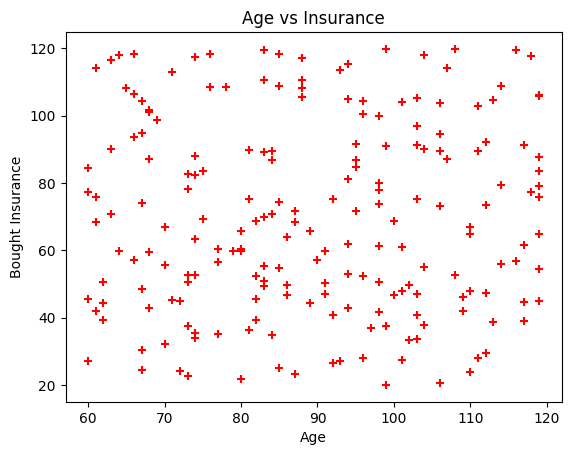

In [ ]:
plt.scatter(df['age'], df['bought_insurance'], marker='+', color='red')
plt.xlabel("Age")
plt.ylabel("Bought Insurance")
plt.title("Age vs Insurance")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['age']]
y = df['bought_insurance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Calculate the median of the original 'bought_insurance' column (which is HRV)
# This is done on the full df to get a representative threshold
median_hrv = df['bought_insurance'].median()

# Binarize y_train and y_test based on the median
y_train_binary = (y_train > median_hrv).astype(int)
y_test_binary = (y_test > median_hrv).astype(int)

model = LogisticRegression()
# Fit the model with the binarized target variable
model.fit(X_train, y_train_binary)

LogisticRegression()

In [ ]:
y_predicted = model.predict(X_test)

print("\nPredicted Values:", y_predicted)
print("\nProbabilities:\n", model.predict_proba(X_test))
print("\nAccuracy:", model.score(X_test, y_test_binary))


Predicted Values: [0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 1 1 1 1
 1 1 0]

Probabilities:
 [[0.50880117 0.49119883]
 [0.48005439 0.51994561]
 [0.51141448 0.48858552]
 [0.4748363  0.5251637 ]
 [0.4696237  0.5303763 ]
 [0.44885068 0.55114932]
 [0.46571853 0.53428147]
 [0.49311618 0.50688382]
 [0.49180928 0.50819072]
 [0.4696237  0.5303763 ]
 [0.52446885 0.47553115]
 [0.46051825 0.53948175]
 [0.46571853 0.53428147]
 [0.48005439 0.51994561]
 [0.45921947 0.54078053]
 [0.50749432 0.49250568]
 [0.50357324 0.49642676]
 [0.45532655 0.54467345]
 [0.52446885 0.47553115]
 [0.4905025  0.5094975 ]
 [0.51794473 0.48205527]
 [0.4748363  0.5251637 ]
 [0.51141448 0.48858552]
 [0.51402717 0.48597283]
 [0.45792126 0.54207874]
 [0.50880117 0.49119883]
 [0.45662361 0.54337639]
 [0.50095891 0.49904109]
 [0.51533324 0.48466676]
 [0.46051825 0.53948175]
 [0.50226609 0.49773391]
 [0.52316462 0.47683538]
 [0.47614035 0.52385965]
 [0.48135963 0.51864037]
 [0.48397088 0.51602912]
 [0.47

In [ ]:
print("\nPrediction for Age 45:", model.predict([[45]]))
print("Probability:", model.predict_proba([[45]]))


Prediction for Age 45: [0]
Probability: [[0.54527913 0.45472087]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
